<h2>AI-Driven Global Semiconductor Supply Chain Risk Intelligence Platform</h2>

In [1]:
%pip install scikit-learn


/Users/atifansari/Documents/GitHub/Semiconductor-Supply-Chain-Risk-Prediction-System/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
#P1 importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

In [3]:
#P2 Loading Dataset
df = pd.read_csv("2ndTRY_semiconductor_supply_chain.csv")

df.head()



,year,reporter,reporter_code,partner,partner_code,flow,flow_code,hs_code,commodity,trade_value_usd,net_weight_kg
0,2018,China,156,USA,842,Import,M,854231,Electronic integrated circuits; processors and...,9.848380e+09,320580.012
1,2018,China,156,USA,842,Import,M,854232,Electronic integrated circuits; memories,7.173663e+08,67885.000
2,2018,China,156,USA,842,Import,M,854239,Electronic integrated circuits; n.e.c. in head...,9.955156e+08,142502.000
3,2018,China,156,USA,842,Export,X,854231,Electronic integrated circuits; processors and...,6.791552e+08,634709.000
4,2018,China,156,USA,842,Export,X,854232,Electronic integrated circuits; memories,6.009548e+08,79592.005


In [4]:
#P3 Inspect Dataset
df.shape

(1764, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1764 entries, 0 to 1763
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             1764 non-null   int64  
 1   reporter         1764 non-null   str    
 2   reporter_code    1764 non-null   int64  
 3   partner          1764 non-null   str    
 4   partner_code     1764 non-null   int64  
 5   flow             1764 non-null   str    
 6   flow_code        1764 non-null   str    
 7   hs_code          1764 non-null   int64  
 8   commodity        1764 non-null   str    
 9   trade_value_usd  1764 non-null   float64
 10  net_weight_kg    1530 non-null   float64
dtypes: float64(2), int64(4), str(5)
memory usage: 151.7 KB


In [6]:
df.describe()

,year,reporter_code,partner_code,hs_code,trade_value_usd,net_weight_kg
count,1764.000000,1764.000000,1764.000000,1764.000000,1.764000e+03,1.530000e+03
mean,2021.000000,472.285714,472.285714,854234.000000,1.274589e+09,2.333839e+05
std,2.000567,220.921804,220.921804,3.560035,4.218120e+09,5.023472e+05
min,2018.000000,156.000000,156.000000,854231.000000,2.311866e+04,0.000000e+00
25%,2019.000000,276.000000,276.000000,854231.000000,5.420065e+07,7.905922e+02
50%,2021.000000,410.000000,410.000000,854232.000000,2.519319e+08,3.480905e+04
75%,2023.000000,702.000000,702.000000,854239.000000,7.848579e+08,2.227426e+05
max,2024.000000,842.000000,842.000000,854239.000000,6.372054e+10,6.157041e+06


In [7]:
df.isnull().sum()

year                 0
reporter             0
reporter_code        0
partner              0
partner_code         0
flow                 0
flow_code            0
hs_code              0
commodity            0
trade_value_usd      0
net_weight_kg      234
dtype: int64

In [8]:
#P4 Basic Cleaning

#remove duplicate rows
df = df.drop_duplicates()

df.shape

(1764, 11)

In [9]:
#convert numeric columns
numeric_cols = [
    "trade_value_usd",
    "net_weight_kg"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [10]:
#handle missing values
imputer = SimpleImputer(strategy="median")

for col in numeric_cols:
    df[[col]] = imputer.fit_transform(df[[col]])

In [11]:
#check if nulls exist
df.isnull().sum()

year               0
reporter           0
reporter_code      0
partner            0
partner_code       0
flow               0
flow_code          0
hs_code            0
commodity          0
trade_value_usd    0
net_weight_kg      0
dtype: int64

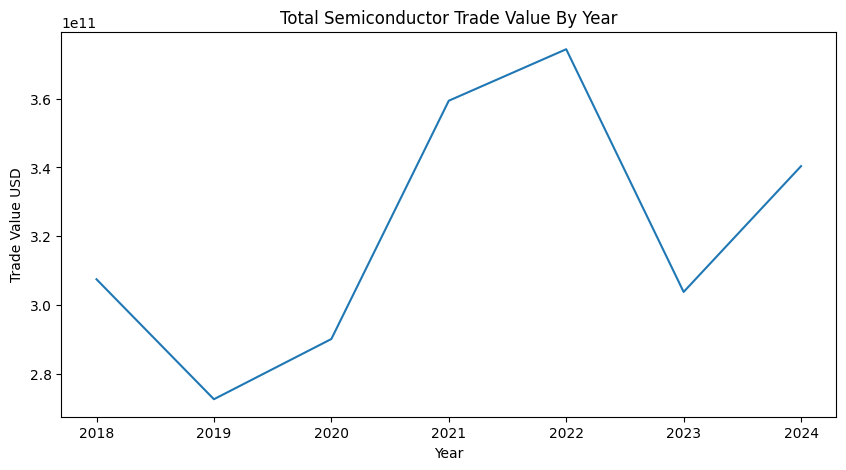

In [12]:
#P5 Exploratory Data Analysis (EDA)

#Total Trade Value By Year
trade_by_year = (
    df.groupby("year")["trade_value_usd"]
    .sum()
)

plt.figure(figsize=(10,5))
plt.plot(trade_by_year.index, trade_by_year.values)
plt.title("Total Semiconductor Trade Value By Year")
plt.xlabel("Year")
plt.ylabel("Trade Value USD")
plt.show()

In [13]:
#Top Trade Relationship
top_pairs = (
    df.groupby(["reporter", "partner"])["trade_value_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_pairs)

reporter       partner      
China          Rep. of Korea    6.391757e+11
Rep. of Korea  China            4.078815e+11
Singapore      China            1.550156e+11
China          Japan            1.433761e+11
Singapore      Rep. of Korea    1.050005e+11
China          USA              9.506715e+10
               Singapore        7.408617e+10
USA            China            7.086038e+10
Japan          China            6.143383e+10
Singapore      Japan            4.704185e+10
Name: trade_value_usd, dtype: float64


In [14]:
#P6 Feature Engineering
'''
This is the MOST important phase.

We will create:

Dependency features

Trend features

Volatility features

Lag features

Disruption indicators
'''

'\nThis is the MOST important phase.\n\nWe will create:\n\nDependency features\n\nTrend features\n\nVolatility features\n\nLag features\n\nDisruption indicators\n'

In [15]:
#P6.1 Sort Dataset
df = df.sort_values(
    by=[
        "reporter",
        "partner",
        "hs_code",
        "flow",
        "year"
    ]
)

In [16]:
#P6.2 Create Lag Feature
#Previous year's trade value.
df["lag_trade_1y"] = (
    df.groupby(
        [
            "reporter",
            "partner",
            "hs_code",
            "flow"
        ]
    )["trade_value_usd"]
    .shift(1)
)

In [17]:
#P6.3 YoY Growth Percentage
#Measures trade shocks.
df["yoy_growth_pct"] = (
    (
        df["trade_value_usd"]
        - df["lag_trade_1y"]
    )
    / df["lag_trade_1y"]
) * 100

In [18]:
#P6.4 Rolling Average
#Trend smoothing.
df["rolling_avg_3y"] = (
    df.groupby(
        [
            "reporter",
            "partner",
            "hs_code",
            "flow"
        ]
    )["trade_value_usd"]
    .transform(
        lambda x:
        x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)


In [19]:
#P6.5 Volatility Index
#Measures instability.
df["volatility_index"] = (
    df.groupby(
        [
            "reporter",
            "partner",
            "hs_code",
            "flow"
        ]
    )["trade_value_usd"]
    .transform(
        lambda x:
        x.rolling(
            window=3,
            min_periods=1
        ).std()
    )
)


In [20]:
#P6.6 Supplier Dependency Ratio
#One of the MOST important features.

#Step 1 — Calculate Total Imports
#The CSV uses singular flow labels: Import / Export.

total_imports = (
    df[df["flow"].eq("Import")]
    .groupby(
        [
            "year",
            "reporter",
            "hs_code"
        ]
    )["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(
        columns={
            "trade_value_usd": "total_imports"
        }
    )
)

total_imports.head()


,year,reporter,hs_code,total_imports
0,2018,China,854231,2.947667e+10
1,2018,China,854232,7.349913e+10
2,2018,China,854239,1.173793e+10
3,2018,Germany,854231,3.786293e+09
4,2018,Germany,854232,1.065984e+09


In [21]:
#Step 2 — Merge Back
df = df.merge(
    total_imports,
    on=[
        "year",
        "reporter",
        "hs_code"
    ],
    how="left"
)

In [22]:
#Step 3 — Calculate Dependency Ratio
#Avoid divide-by-zero or missing import totals.
df["supplier_dependency_ratio"] = np.where(
    df["total_imports"].gt(0),
    df["trade_value_usd"] / df["total_imports"],
    np.nan
)


In [23]:
#P6.7 Sudden Drop Flag
#Creates disruption indicators.
df["sudden_drop_flag"] = (
    df["yoy_growth_pct"] < -20
).astype(int)


In [24]:
#P6.8 Create Future Trade Label
#THIS is our ML target.

#Goal:
#Predict next year's bilateral trade value

df["future_trade_value_usd"] = (
    df.groupby(
        [
            "reporter",
            "partner",
            "hs_code",
            "flow"
        ]
    )["trade_value_usd"]
    .shift(-1)
)

In [25]:
#P7 Remove Missing Rows
#Lag, rolling std, and the future label create NaNs at group edges.
#Only drop rows that are missing columns required for modeling.

required_model_cols = [
    "trade_value_usd",
    "net_weight_kg",
    "lag_trade_1y",
    "yoy_growth_pct",
    "rolling_avg_3y",
    "volatility_index",
    "supplier_dependency_ratio",
    "sudden_drop_flag",
    "future_trade_value_usd",
]

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=required_model_cols)

print("Rows available for ML:", len(df))
df.shape


Rows available for ML: 1260


(1260, 19)

In [26]:
#P8 Feature Selection

#Input Features (X)
features = [
    "trade_value_usd",
    "net_weight_kg",
    "lag_trade_1y",
    "yoy_growth_pct",
    "rolling_avg_3y",
    "volatility_index",
    "supplier_dependency_ratio",
    "sudden_drop_flag"
]

#Target Variable (y)
target = "future_trade_value_usd"

In [27]:
#P9 Prepare ML Dataset
X = df[features]
y = df[target]

In [28]:
#P10 Train/Test Split
if len(df) < 2:
    raise ValueError(
        "No rows are available for training. Re-run the cleaning and feature engineering cells "
        "and check that flow values are Import/Export."
    )

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))


Train rows: 1008
Test rows: 252


In [29]:
#P11 Train Machine Learning Model
'''
We will use:

Random Forest Regressor

Excellent baseline model.
'''

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [30]:
#P12 Predictions
y_pred = model.predict(X_test)


In [31]:
#P13 Model Evaluation

#Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

#Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

#R^2 Score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


MAE: 332691435.02103424
RMSE: 1149301226.388323
R² Score: 0.9519805122061701


In [32]:
#MAE : Lower (Good Value)
#RMSE : Lower (Good Value)
#R² Score : Closer to 1 (Good Value)

In [33]:
#P14 Feature Importance
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)



                     Feature  Importance
0            trade_value_usd    0.592012
4             rolling_avg_3y    0.235934
2               lag_trade_1y    0.099010
5           volatility_index    0.052870
3             yoy_growth_pct    0.007579
1              net_weight_kg    0.006367
6  supplier_dependency_ratio    0.005874
7           sudden_drop_flag    0.000354


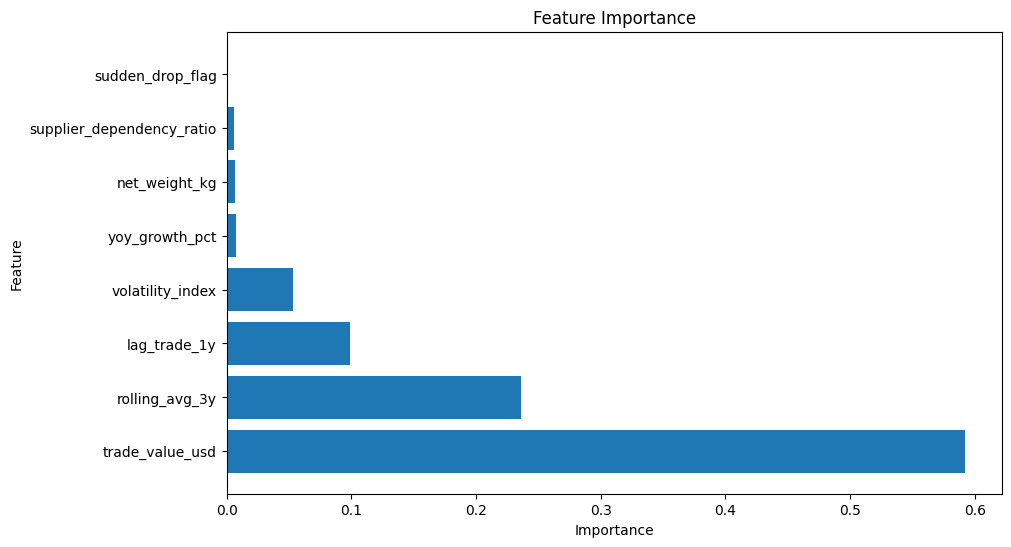

In [34]:
#Plotting Feature Importance
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [35]:
'''
Our system can now infer:

high dependency relationships

unstable suppliers

volatile trade routes

disruption-prone country pairs
'''

'\nOur system can now infer:\n\nhigh dependency relationships\n\nunstable suppliers\n\nvolatile trade routes\n\ndisruption-prone country pairs\n'

In [36]:
'''Example Insights

Example 1

If:

supplier_dependency_ratio = high

volatility_index = high

yoy_growth_pct = strongly negative

Then:

Supply chain risk is HIGH

Example 2

If:

dependency low

stable rolling averages

low volatility

Then:

Supply chain relationship is stable

'''

'Example Insights\n\nExample 1\n\nIf:\n\nsupplier_dependency_ratio = high\n\nvolatility_index = high\n\nyoy_growth_pct = strongly negative\n\nThen:\n\nSupply chain risk is HIGH\n\nExample 2\n\nIf:\n\ndependency low\n\nstable rolling averages\n\nlow volatility\n\nThen:\n\nSupply chain relationship is stable\n\n'

In [37]:
df.info()

<class 'pandas.DataFrame'>
Index: 1260 entries, 1 to 1762
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       1260 non-null   int64  
 1   reporter                   1260 non-null   str    
 2   reporter_code              1260 non-null   int64  
 3   partner                    1260 non-null   str    
 4   partner_code               1260 non-null   int64  
 5   flow                       1260 non-null   str    
 6   flow_code                  1260 non-null   str    
 7   hs_code                    1260 non-null   int64  
 8   commodity                  1260 non-null   str    
 9   trade_value_usd            1260 non-null   float64
 10  net_weight_kg              1260 non-null   float64
 11  lag_trade_1y               1260 non-null   float64
 12  yoy_growth_pct             1260 non-null   float64
 13  rolling_avg_3y             1260 non-null   float64
 14  volatili

In [38]:
#Export 'df' to CSV
df.to_csv("from_V1_supply_chain_data.csv", index=False)


In [39]:
# Export trained V1 model for Streamlit deployment
import joblib

export_obj = {
    'model': model,
    'features': features
}
# include imputer if present
if 'imputer' in globals():
    export_obj['imputer'] = imputer

joblib.dump(export_obj, 'model_v1.pkl')
print('Saved model_v1.pkl')

Saved model_v1.pkl


In [42]:
pip install streamlit pandas numpy scikit-learn joblib

/Users/atifansari/Documents/GitHub/Semiconductor-Supply-Chain-Risk-Prediction-System/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import streamlit as st
import pandas as pd
import numpy as np
import sklearn
import joblib
import matplotlib

# Install required packages into the current notebook kernel
%pip install --quiet streamlit pandas numpy scikit-learn joblib matplotlib

# Verify installation from Python

print("streamlit:", st.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("matplotlib:", matplotlib.__version__)

ModuleNotFoundError: No module named 'streamlit'

In [4]:
import sys
!streamlit --version

zsh:1: command not found: streamlit
